# Hands-On-Activity 7.2 | CNN Architectures from Scratch and Transfer Learning

## Procedure

1. Create a VGG-16 Network from scratch.

2. Train on the given [dataset](https://www.kaggle.com/datasets/samrat230599/fastai-imagenet/data). and reach at least 95% Accuracy. Do not use pre-trained weights.

3. Plot the accuracy for both Training and Validation. Include a confusion matrix, and a classification report (Precision, Recall , F1 score, Sensitivity) Plot the ROC AUC score result of the model

4. Interpret and evaluate the result of the model.

5. Import a pretrained VGG-16 Network, adjust the final layers to match the dataset. Must have pre-trained weights.

6. Fine tune on the given dataset, plot the same metrics in #3 and #4.

7. Compare the results of the trained network from scratch and fine-tuned network.

### Import Data

In [10]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/hoa7.2/FastAI_ImageNet_v2'

# 3. Check it looks right
import os
print(os.listdir(data_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Training.csv', 'Validation.csv', 'training_composition.txt', 'validation_composition.txt', 'train', 'val']


In [11]:
# Fix — rename extensions to lowercase
import pathlib

count = 0
for split in ['train', 'val']:
    for cls in os.listdir(f'{data_dir}/{split}'):
        cls_path = f'{data_dir}/{split}/{cls}'
        for f in pathlib.Path(cls_path).iterdir():
            if f.suffix == '.JPEG':
                f.rename(f.with_suffix('.jpeg'))
                count += 1

print(f"Renamed {count} files")

Renamed 0 files


In [12]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_set = ImageFolder(root=f'{data_dir}/train', transform=transform_train)
val_set   = ImageFolder(root=f'{data_dir}/val',   transform=transform_val)
class_names = train_set.classes
print(f"Classes: {class_names}")

train_loader = DataLoader(train_set, batch_size=20, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=20, shuffle=False, num_workers=2)

print(f"Training samples (full): {len(train_set)}")
print(f"Validation samples (full): {len(val_set)}")

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")

Classes: ['cassette_player', 'chain_saw', 'church', 'english_springer', 'french_horn', 'garbage_truck', 'gas_pump', 'golf_ball', 'parachute', 'tench']
Training samples (full): 9469
Validation samples (full): 3925
Batch shape: torch.Size([20, 3, 224, 224])


THe data augmentation techniques used include RandomHorizontalFlip and ColorJitter. The batch size was also set to 20 (between 16 and 32).

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


### VGG-16 from scratch

In [14]:
import torch.nn as nn

class VGG16Scratch(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG16Scratch, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))

        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(4096, 4096),        nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(4096, num_classes),
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

model_scratch = VGG16Scratch(num_classes=10).to(device)
print(f"Total parameters: {sum(p.numel() for p in model_scratch.parameters()):,}")

Total parameters: 134,309,962


### View dataset contents

Label indices: [4, 5, 5, 8, 2, 0, 3, 1]
Label names:   ['french_horn', 'garbage_truck', 'garbage_truck', 'parachute', 'church', 'cassette_player', 'english_springer', 'chain_saw']


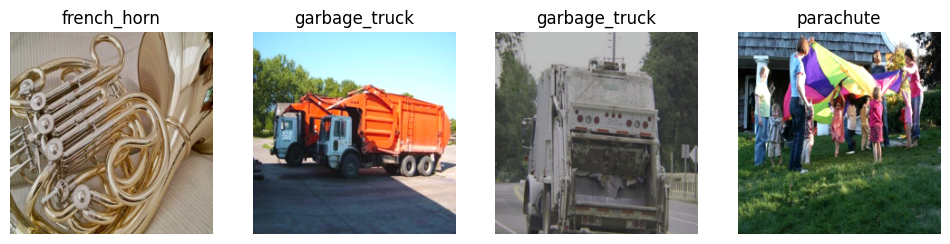

In [15]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
print(f"Label indices: {labels[:8].tolist()}")
print(f"Label names:   {[class_names[i] for i in labels[:8].tolist()]}")

# visually check a few images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  #unnormalize
    img = img.clip(0, 1)
    ax.imshow(img)
    ax.set_title(class_names[labels[i]])
    ax.axis('off')
plt.show()

### Train model

An AdamW optimizer is used, as well as a scheduler to adjust the learning rate if the results plateau at some point. Furthermore, gradient clipping was also used so that the performance doesn't dip suddenly across training epochs. As a last resort, early stopping was also used to conserve runtime resources.

In [18]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import autocast, GradScaler

model_scratch = VGG16Scratch(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_scratch.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)
scaler    = GradScaler('cuda')

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                epochs=50, early_stop_patience=10):          # ← added early_stop_patience
    history       = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    total_train   = len(train_loader.dataset)
    total_val     = len(val_loader.dataset)
    total_batches = len(train_loader)
    first_95      = None

    # Early stopping state
    best_val_acc    = 0.0
    patience_counter = 0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1} -------------------------------")

        # ── Training ──
        model.train()
        train_loss, train_correct, total = 0, 0, 0

        for batch, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with autocast('cuda'):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss    += loss.item() * images.size(0)
            train_correct += outputs.argmax(1).eq(labels).sum().item()
            total         += images.size(0)

            if (batch + 1) % (total_batches // 8) == 0 or total == total_train:
                print(f"  loss: {loss.item():.6f}  acc: {train_correct/total*100:.1f}%  [{total:>4}/{total_train}]")

        train_loss /= total_train
        train_acc   = train_correct / total_train
        print(f"Train:\n  Accuracy: {train_acc*100:.1f}%  |  Avg loss: {train_loss:.6f}")

        # Validation
        print("Validating...", end=' ', flush=True)
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for batch, (images, labels) in enumerate(val_loader):
                images, labels = images.to(device), labels.to(device)

                with autocast('cuda'):
                    outputs = model(images)
                    loss    = criterion(outputs, labels)

                val_loss    += loss.item() * images.size(0)
                val_correct += outputs.argmax(1).eq(labels).sum().item()
                val_total   += images.size(0)

                if (batch + 1) % 10 == 0 or val_total == total_val:
                    print(f"[{val_total}/{total_val}]", end=' ', flush=True)

        print()
        val_loss /= total_val
        val_acc   = val_correct / total_val

        scheduler.step(val_acc)

        print(f"Val:\n  Accuracy: {val_acc*100:.1f}%  |  Avg loss: {val_loss:.6f}")

        #  95% check
        if val_acc >= 0.95 and first_95 is None:
            first_95 = epoch + 1
            print(f"First reached 95% at epoch {first_95}! Continuing training...")
            torch.save(model.state_dict(), 'vgg16_scratch_best.pth')

        # Early stopping check
        if val_acc > best_val_acc:
            best_val_acc     = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'vgg16_scratch_best.pth')  # save best
            print(f"  ↑ New best val acc: {best_val_acc*100:.1f}%")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{early_stop_patience}")
            if patience_counter >= early_stop_patience:
                print(f"Early stopping at epoch {epoch+1} — no improvement for {early_stop_patience} epochs")
                break

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

    if first_95:
        print(f"\nFirst hit 95% at epoch {first_95} | Best Val Acc: {best_val_acc*100:.1f}%")
    else:
        print(f"\n95% was never reached | Best Val Acc: {best_val_acc*100:.1f}%")

    return history



In [19]:
history_scratch = train_model(
    model_scratch, train_loader, val_loader,
    criterion, optimizer, scheduler,
    epochs=67, #67
    early_stop_patience=10
)



Epoch 1 -------------------------------
  loss: 2.196213  acc: 14.8%  [1180/9469]
  loss: 2.163279  acc: 20.6%  [2360/9469]
  loss: 2.257261  acc: 25.2%  [3540/9469]
  loss: 1.780414  acc: 28.7%  [4720/9469]
  loss: 1.653492  acc: 31.0%  [5900/9469]
  loss: 1.788875  acc: 33.2%  [7080/9469]
  loss: 1.674338  acc: 35.5%  [8260/9469]
  loss: 1.631535  acc: 37.2%  [9440/9469]
  loss: 1.705057  acc: 37.3%  [9469/9469]
Train:
  Accuracy: 37.3%  |  Avg loss: 1.966521
Validating... [200/3925] [400/3925] [600/3925] [800/3925] [1000/3925] [1200/3925] [1400/3925] [1600/3925] [1800/3925] [2000/3925] [2200/3925] [2400/3925] [2600/3925] [2800/3925] [3000/3925] [3200/3925] [3400/3925] [3600/3925] [3800/3925] [3925/3925] 
Val:
  Accuracy: 49.1%  |  Avg loss: 1.672792
  ↑ New best val acc: 49.1%

Epoch 2 -------------------------------
  loss: 1.398949  acc: 51.5%  [1180/9469]
  loss: 1.879466  acc: 51.9%  [2360/9469]
  loss: 1.328110  acc: 54.1%  [3540/9469]
  loss: 1.430331  acc: 55.1%  [4720/9469]

While the training was meant for 67 epochs, early stopping halted it prematurely as no improvement has been seen. Overall, the model trained for 64 epochs, achieving an accuracy of 89.8% at its peak.

#### Evaluation

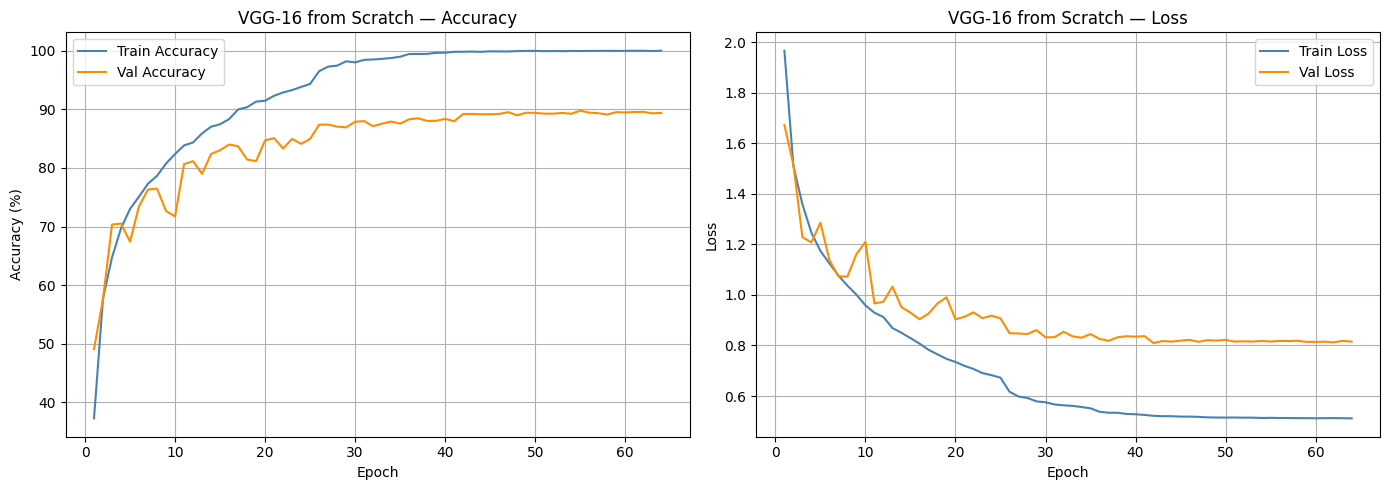

In [20]:
import matplotlib.pyplot as plt

def plot_history(history, title='VGG-16 from Scratch'):
    epochs = range(1, len(history['train_acc']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, [a*100 for a in history['train_acc']], label='Train Accuracy', color='steelblue')
    ax1.plot(epochs, [a*100 for a in history['val_acc']],   label='Val Accuracy',   color='darkorange')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy (%)')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, history['train_loss'], label='Train Loss', color='steelblue')
    ax2.plot(epochs, history['val_loss'],   label='Val Loss',   color='darkorange')
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_scratch, title='VGG-16 from Scratch')

The graphs show the importance of gradient clipping, as it kept the accuracy values consistent across training epochs. However, it seems that the model overfits once it reaches the 75%-80% validation accuracy threshold.

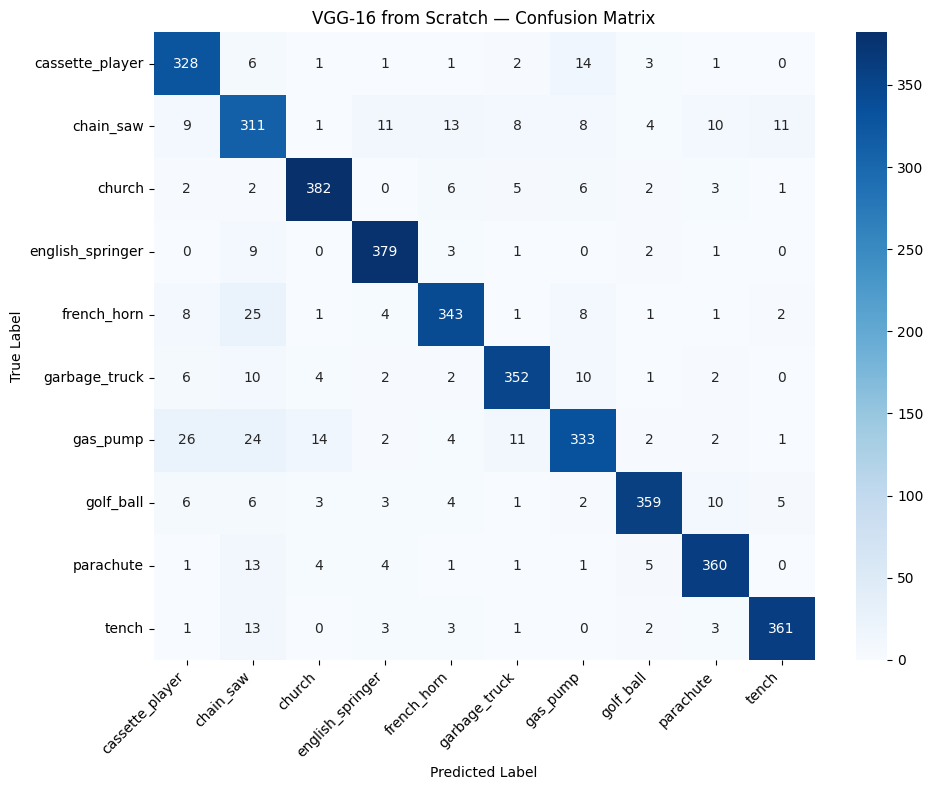


VGG-16 from Scratch — Classification Report

                  precision    recall  f1-score   support

 cassette_player       0.85      0.92      0.88       357
       chain_saw       0.74      0.81      0.77       386
          church       0.93      0.93      0.93       409
english_springer       0.93      0.96      0.94       395
     french_horn       0.90      0.87      0.89       394
   garbage_truck       0.92      0.90      0.91       389
        gas_pump       0.87      0.79      0.83       419
       golf_ball       0.94      0.90      0.92       399
       parachute       0.92      0.92      0.92       390
           tench       0.95      0.93      0.94       387

        accuracy                           0.89      3925
       macro avg       0.89      0.89      0.89      3925
    weighted avg       0.90      0.89      0.89      3925



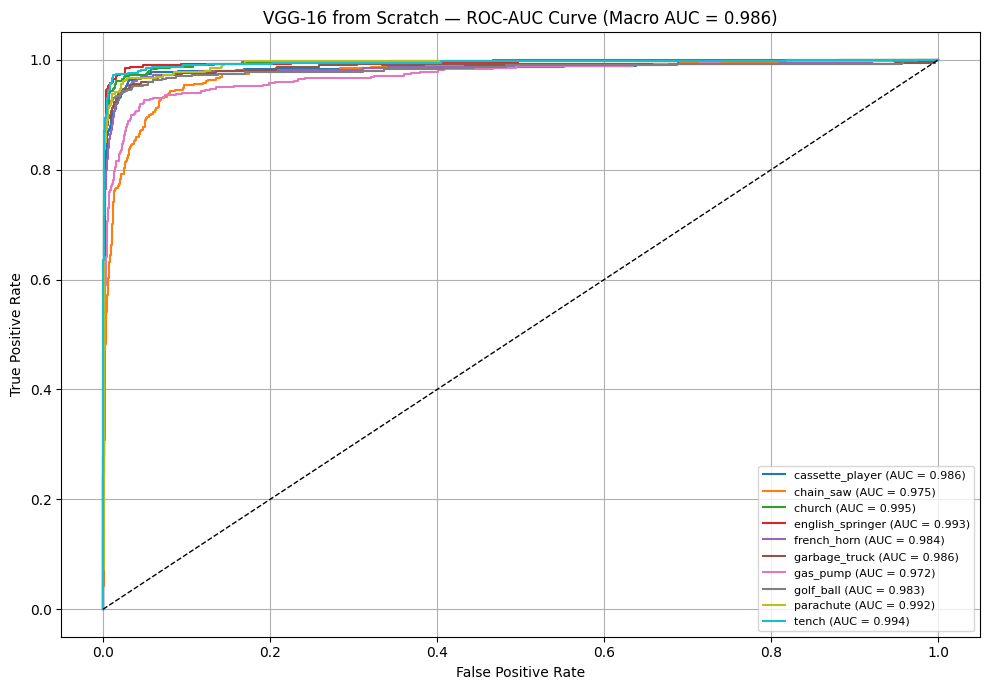

In [21]:
import numpy as np
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F

def evaluate_model(model, val_loader, class_names, title='Model'):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs   = F.softmax(outputs, dim=1).cpu().numpy()
            preds   = outputs.argmax(1).cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    # ── Confusion Matrix ──
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title} — Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # ── Classification Report ──
    print(f"\n{title} — Classification Report\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # ── ROC-AUC ──
    n_classes = len(class_names)
    labels_bin = label_binarize(all_labels, classes=range(n_classes))

    plt.figure(figsize=(10, 7))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
        auc = roc_auc_score(labels_bin[:, i], all_probs[:, i])
        plt.plot(fpr, tpr, label=f'{cls} (AUC = {auc:.3f})')

    macro_auc = roc_auc_score(labels_bin, all_probs, average='macro', multi_class='ovr')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.title(f'{title} — ROC-AUC Curve (Macro AUC = {macro_auc:.3f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return all_labels, all_preds, all_probs

labels_s, preds_s, probs_s = evaluate_model(
    model_scratch, val_loader, class_names, title='VGG-16 from Scratch'
)

However, one positive that can be noted is that its ROC-AUC values across all 10 classes are high enough, which means that the model can clearly understand the differences within these classes and are able to discriminate them from each other.

### Pre-trained VGG-16 network

####Pre-trained model

In [22]:
import torchvision.models as models

# Load pretrained VGG-16
model_pretrained = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all feature extractor layers
for param in model_pretrained.features.parameters():
    param.requires_grad = False

# Replace classifier to match 10 classes
model_pretrained.classifier = nn.Sequential(
    nn.Linear(512 * 7 * 7, 4096), nn.ReLU(inplace=True), nn.Dropout(0.32),
    nn.Linear(4096, 4096),        nn.ReLU(inplace=True), nn.Dropout(0.32),
    nn.Linear(4096, 10),
)

model_pretrained = model_pretrained.to(device)

# Only train the classifier
optimizer_pt = optim.Adam(model_pretrained.classifier.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_pt = ReduceLROnPlateau(optimizer_pt, mode='max', patience=3, factor=0.5)

print("Pretrained VGG-16 loaded. Classifier layers unfrozen for fine-tuning.")
print(f"Trainable parameters: {sum(p.numel() for p in model_pretrained.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 75.0MB/s]


Pretrained VGG-16 loaded. Classifier layers unfrozen for fine-tuning.
Trainable parameters: 119,586,826


For the pretrained model, all the layers were freezed except the last, which was finetuned.

### Train model


Epoch 1 -------------------------------
  loss: 0.700610  acc: 91.6%  [1180/9469]
  loss: 0.581763  acc: 93.2%  [2360/9469]
  loss: 0.654041  acc: 93.9%  [3540/9469]
  loss: 0.700187  acc: 94.5%  [4720/9469]
  loss: 0.592728  acc: 95.0%  [5900/9469]
  loss: 0.626957  acc: 95.1%  [7080/9469]
  loss: 0.629028  acc: 95.5%  [8260/9469]
  loss: 0.663710  acc: 95.7%  [9440/9469]
  loss: 0.546260  acc: 95.7%  [9469/9469]
Train:
  Accuracy: 95.7%  |  Avg loss: 0.693258
Validating... [200/3925] [400/3925] [600/3925] [800/3925] [1000/3925] [1200/3925] [1400/3925] [1600/3925] [1800/3925] [2000/3925] [2200/3925] [2400/3925] [2600/3925] [2800/3925] [3000/3925] [3200/3925] [3400/3925] [3600/3925] [3800/3925] [3925/3925] 
Val:
  Accuracy: 97.5%  |  Avg loss: 0.615055
First reached 95% at epoch 1! Continuing training...
  ↑ New best val acc: 97.5%

Epoch 2 -------------------------------
  loss: 0.617232  acc: 99.2%  [1180/9469]
  loss: 0.647042  acc: 98.8%  [2360/9469]
  loss: 0.555601  acc: 98.9%  

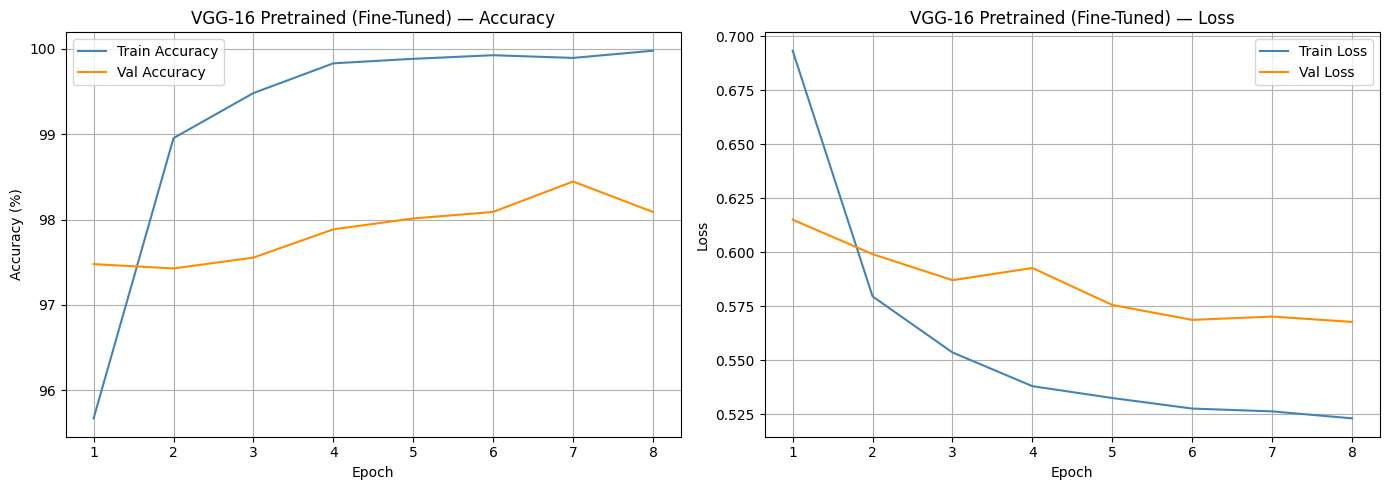

In [26]:
scaler = GradScaler('cuda')

history_pretrained = train_model(
    model_pretrained, train_loader, val_loader,
    criterion, optimizer_pt, scheduler_pt, epochs=10, early_stop_patience=2
)

plot_history(history_pretrained, title='VGG-16 Pretrained (Fine-Tuned)')

#### Evaluation

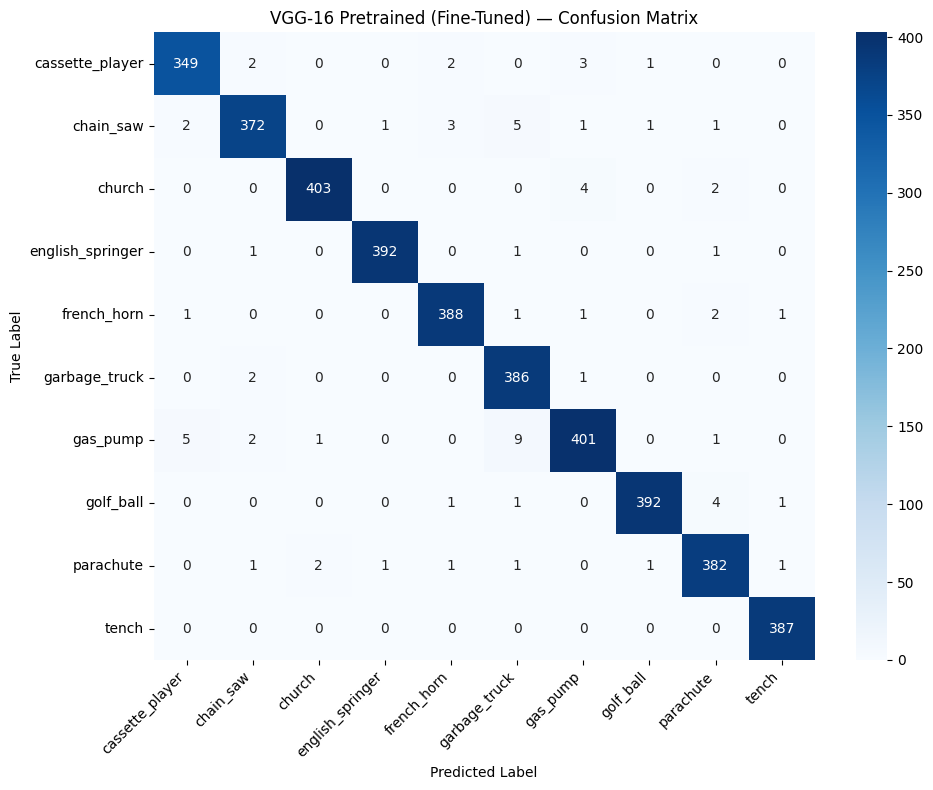


VGG-16 Pretrained (Fine-Tuned) — Classification Report

                  precision    recall  f1-score   support

 cassette_player       0.98      0.98      0.98       357
       chain_saw       0.98      0.96      0.97       386
          church       0.99      0.99      0.99       409
english_springer       0.99      0.99      0.99       395
     french_horn       0.98      0.98      0.98       394
   garbage_truck       0.96      0.99      0.97       389
        gas_pump       0.98      0.96      0.97       419
       golf_ball       0.99      0.98      0.99       399
       parachute       0.97      0.98      0.98       390
           tench       0.99      1.00      1.00       387

        accuracy                           0.98      3925
       macro avg       0.98      0.98      0.98      3925
    weighted avg       0.98      0.98      0.98      3925



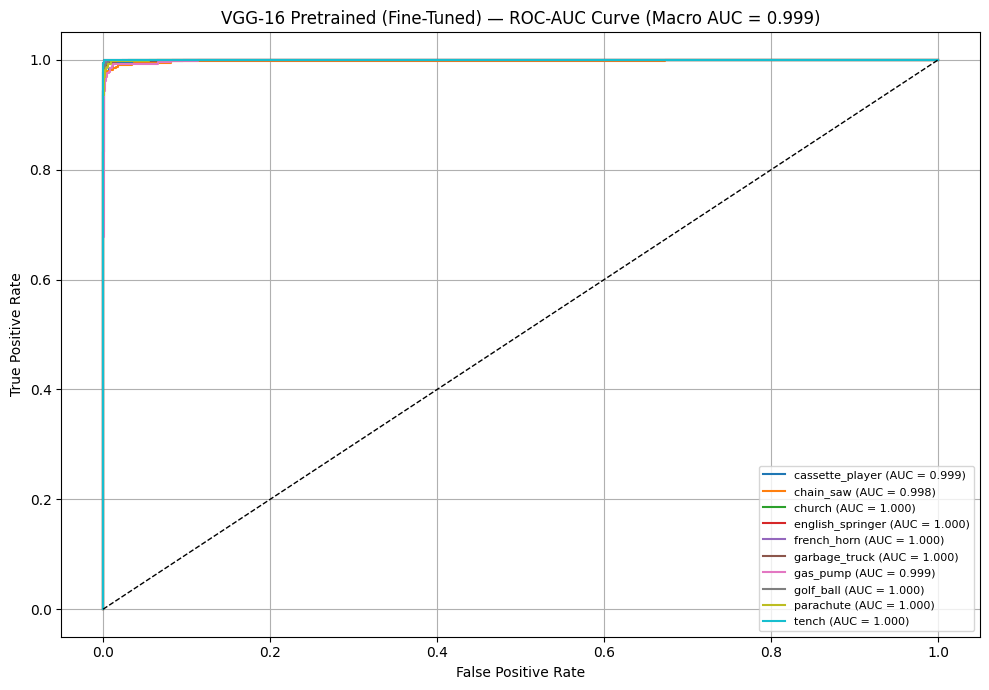

In [27]:
labels_pt, preds_pt, probs_pt = evaluate_model(
    model_pretrained, val_loader, class_names, title='VGG-16 Pretrained (Fine-Tuned)'
)

The pretrained reached the desired accuracy right from the start, and was almost perfect across the board. Nothing much to say here.

### Comparing Both Models

Metric                       Scratch   Pretrained
Val Accuracy                  89.38%       98.14%
Macro ROC-AUC                 0.9858       0.9994
Epochs Trained                    64            8


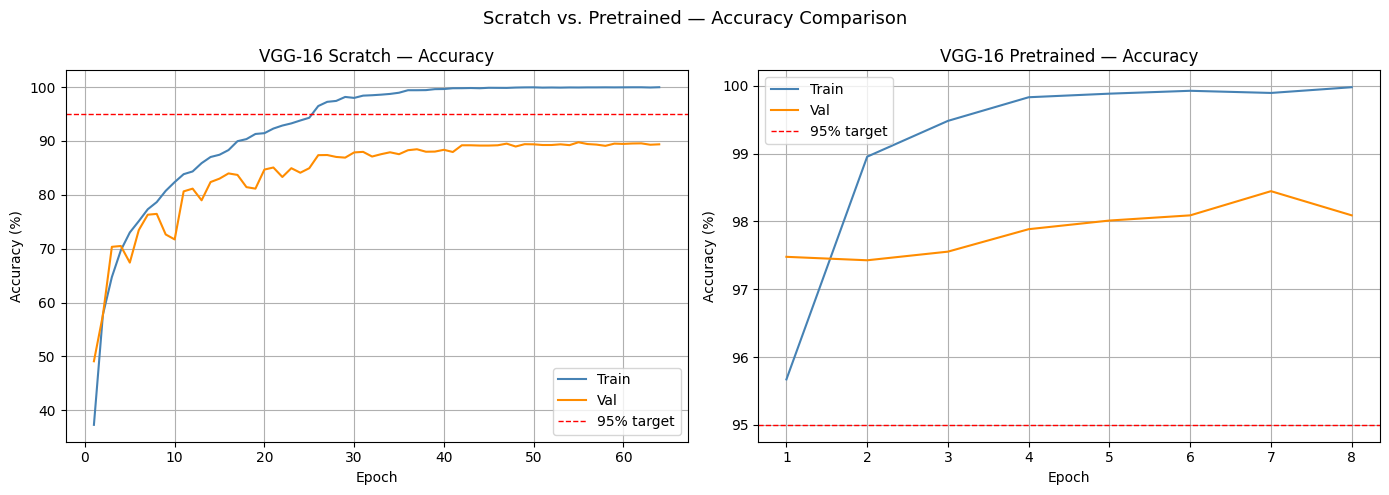

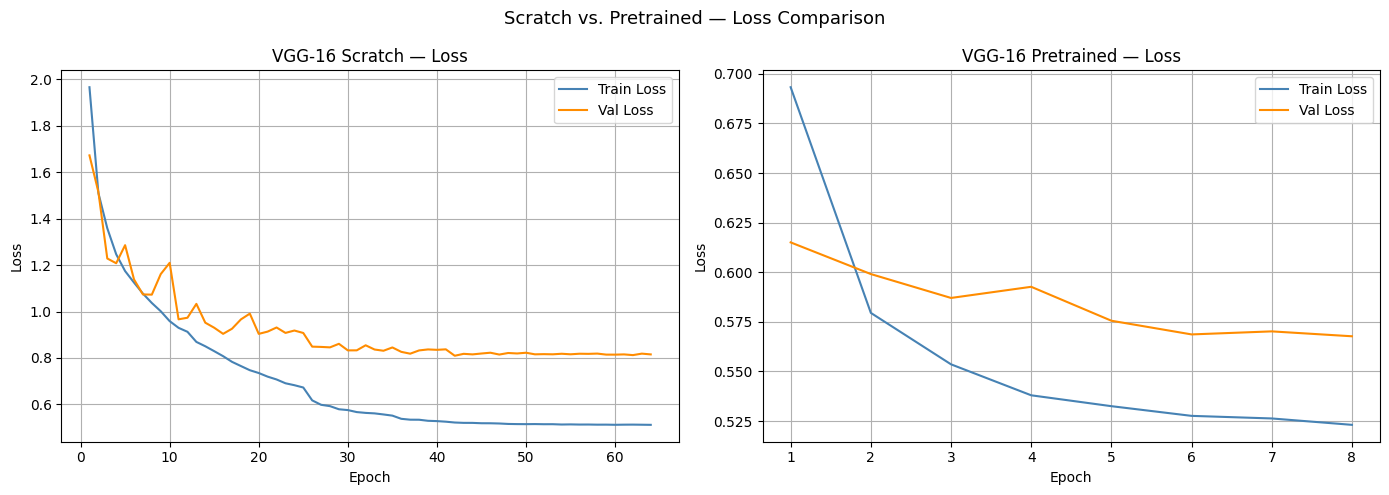

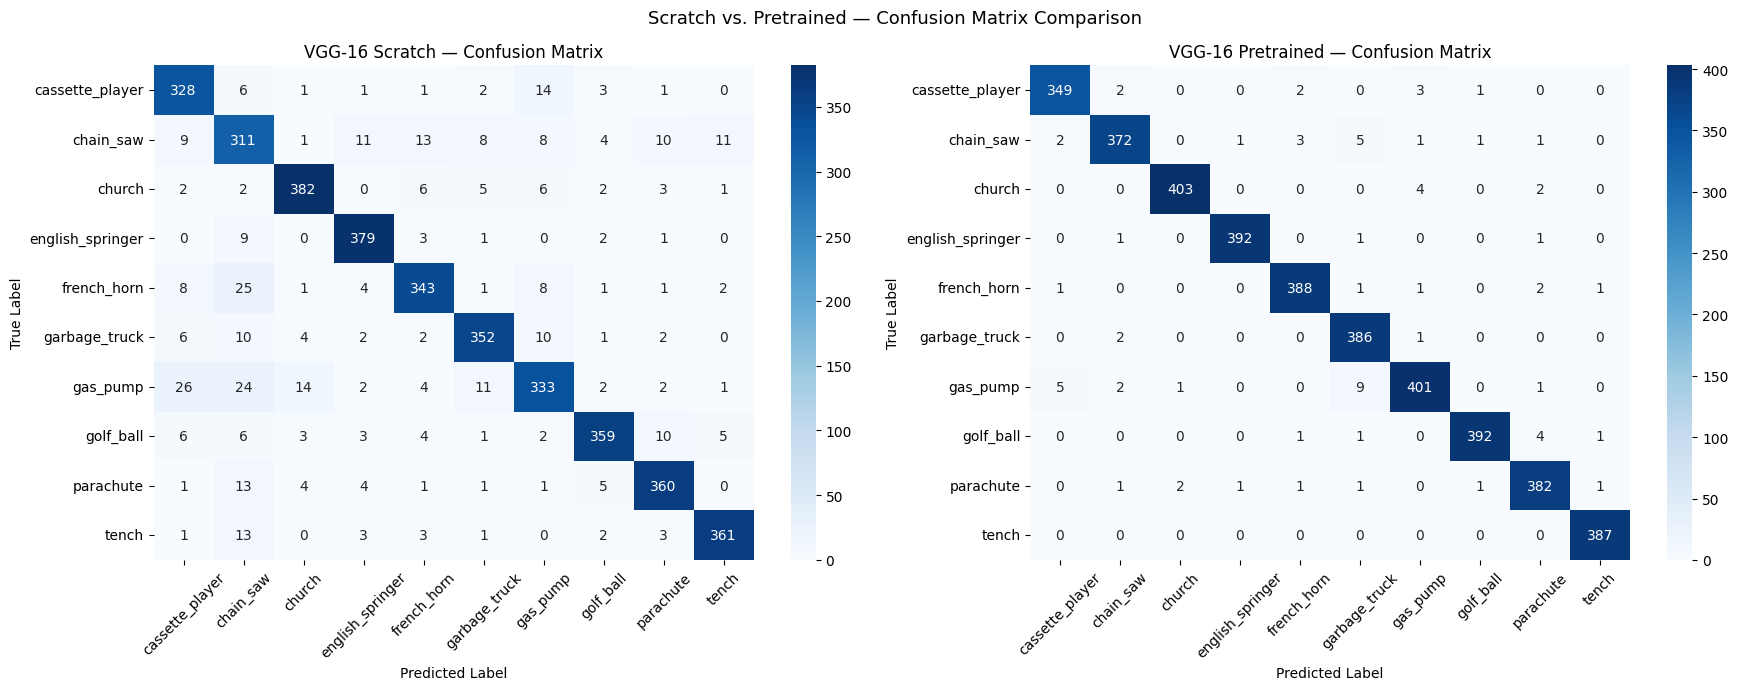

In [29]:
from sklearn.metrics import accuracy_score

acc_scratch    = accuracy_score(labels_s,  preds_s)
acc_pretrained = accuracy_score(labels_pt, preds_pt)

labels_bin     = label_binarize(labels_s, classes=range(10))
auc_scratch    = roc_auc_score(labels_bin, probs_s,  average='macro', multi_class='ovr')
auc_pretrained = roc_auc_score(labels_bin, probs_pt, average='macro', multi_class='ovr')

# ── Summary Table ─────────────────────────────────────────────────────────
print("=" * 50)
print(f"{'Metric':<25} {'Scratch':>10} {'Pretrained':>12}")
print("=" * 50)
print(f"{'Val Accuracy':<25} {acc_scratch*100:>9.2f}% {acc_pretrained*100:>11.2f}%")
print(f"{'Macro ROC-AUC':<25} {auc_scratch:>10.4f} {auc_pretrained:>12.4f}")
print(f"{'Epochs Trained':<25} {len(history_scratch['train_acc']):>10} {len(history_pretrained['train_acc']):>12}")
print("=" * 50)

# ── Accuracy Curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, label in zip(axes,
                               [history_scratch, history_pretrained],
                               ['Scratch', 'Pretrained']):
    epochs = range(1, len(history['train_acc']) + 1)
    ax.plot(epochs, [a*100 for a in history['train_acc']], label='Train', color='steelblue')
    ax.plot(epochs, [a*100 for a in history['val_acc']],   label='Val',   color='darkorange')
    ax.axhline(y=95, color='red', linestyle='--', linewidth=1, label='95% target')
    ax.set_title(f'VGG-16 {label} — Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True)

plt.suptitle('Scratch vs. Pretrained — Accuracy Comparison', fontsize=13)
plt.tight_layout()
plt.show()

# ── Loss Curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, label in zip(axes,
                               [history_scratch, history_pretrained],
                               ['Scratch', 'Pretrained']):
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], label='Train Loss', color='steelblue')
    ax.plot(epochs, history['val_loss'],   label='Val Loss',   color='darkorange')
    ax.set_title(f'VGG-16 {label} — Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

plt.suptitle('Scratch vs. Pretrained — Loss Comparison', fontsize=13)
plt.tight_layout()
plt.show()

# ── Side-by-side Confusion Matrix ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, labels_true, preds, label in zip(axes,
                                          [labels_s,  labels_pt],
                                          [preds_s,   preds_pt],
                                          ['Scratch', 'Pretrained']):
    cm = confusion_matrix(labels_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax)
    ax.set_title(f'VGG-16 {label} — Confusion Matrix')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Scratch vs. Pretrained — Confusion Matrix Comparison', fontsize=13)
plt.tight_layout()
plt.show()

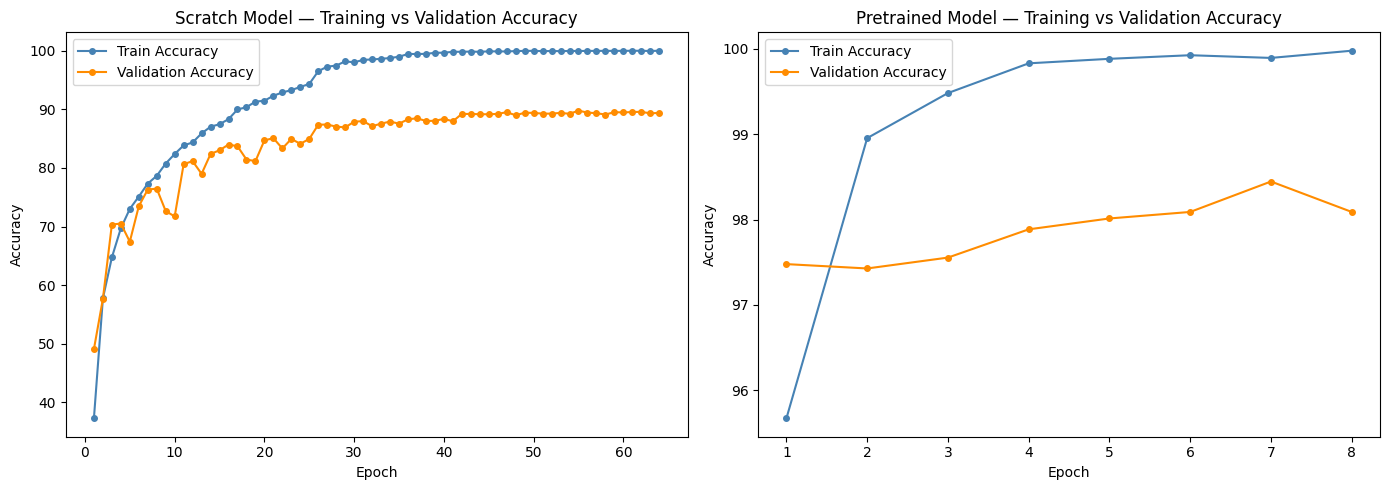

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, label in zip(axes,
                               [history_scratch, history_pretrained],
                               ['Scratch Model', 'Pretrained Model']):
    epochs = range(1, len(history['train_acc']) + 1)
    ax.plot(epochs, [a*100 for a in history['train_acc']],
            label='Train Accuracy', color='steelblue', marker='o', markersize=4)
    ax.plot(epochs, [a*100 for a in history['val_acc']],
            label='Validation Accuracy', color='darkorange', marker='o', markersize=4)
    ax.set_title(f'{label} — Training vs Validation Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(False)

plt.tight_layout()
plt.show()

The graphs show the differences between models trained from scratch and models that were pretrained and then finetuned for a specific purpose. Pretrained models are better trained, and thus produce better results. One thing that pretrained models have over models made from scratch is the training time. Models made from scratch took hours to train, all to yield subpar accuracy, while pretrained models shorter time to produce nearly perfect results.